# 동원 12개월 수요예측 파이프라인 (Persona × OpenAI API × 이벤트/광고 보정)

이 노트북은 다음을 수행합니다.

1. `product_info.csv`를 로드하고 제품 목록을 확보합니다.  
2. (선택) `persona_core.json`의 원시 페르소나를 OpenAI Responses API로 **정형화된 persona prior**(월별 구매확률/빈도, SKU 믹스 등)로 변환합니다.  
3. 페르소나 기반 구매 시뮬레이션을 수행하고, **이벤트/광고/CCSI/월간 캡/500·900g 20% 믹스** 보정을 적용해 12개월(2024-07 ~ 2025-06) 예측을 생성합니다.  
4. 제출 포맷(`months_since_launch_1..12`)의 `submission.csv`를 저장합니다.

> ⚙️ **사전 준비**  
> - Python 3.9+ 권장, `pip install --upgrade openai pyyaml pandas numpy`  
> - OpenAI API 키 환경변수 `OPENAI_API_KEY` 필요 (선택 단계 실행 시).  
> - 파일 경로를 아래 **설정 셀**에서 수정하세요.


In [1]:
# (필요 시) 패키지 설치
# 주석 해제하여 사용하세요. 이 노트북 내부에서는 네트워크가 막혀 있을 수 있습니다.
!pip install --upgrade openai pyyaml pandas numpy matplotlib



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os, json, math, re, sys, time, textwrap, itertools
from pathlib import Path
from dataclasses import dataclass
from typing import List, Dict, Any
import numpy as np
import pandas as pd
from dotenv import load_dotenv

# ====== 경로 설정 (필요 시 수정) ======
# 예시: 업로드하신 파일 경로
PRODUCT_INFO_PATH = Path('product_info1.csv')   # <- 제품 리스트 CSV (필수: product_name 컬럼)
PERSONA_CORE_PATH = Path('persona_core.json')       # <- 원시 페르소나 (선택)
OUTPUT_SUBMISSION_PATH = Path('submission.csv')     # <- 제출 파일 저장 위치
PERSONA_PRIOR_OUT_PATH = Path('persona_prior.json') # <- OpenAI 변환 결과 저장 위치

# OpenAI 모델명 (Responses API)
OPENAI_MODEL = 'gpt-4o-mini'  # 필요 시 'gpt-4o-mini' 등으로 교체
# openai api key 로드
load_dotenv()  # .env 파일에서 환경 변수 로드
os.environ.get('OPENAI_API_KEY') and print('✅ OPENAI_API_KEY 감지됨')

# 유틸
MONTHS = pd.period_range('2024-07', '2025-06', freq='M').strftime('%Y-%m').tolist()
SUBMIT_COLS = [f'months_since_launch_{i}' for i in range(1, 13)]
print('예측 대상 월:', MONTHS)


✅ OPENAI_API_KEY 감지됨
예측 대상 월: ['2024-07', '2024-08', '2024-09', '2024-10', '2024-11', '2024-12', '2025-01', '2025-02', '2025-03', '2025-04', '2025-05', '2025-06']


In [3]:
# 1) 제품 정보 로드
assert PRODUCT_INFO_PATH.exists(), f'제품 파일을 찾지 못했습니다: {PRODUCT_INFO_PATH}'
df_products = pd.read_csv(PRODUCT_INFO_PATH)
if 'product_name' not in df_products.columns:
    raise ValueError('product_info.csv에는 최소 product_name 컬럼이 필요합니다.')
print('제품 수:', len(df_products))
df_products.head()

제품 수: 15


,product_name,product_feature,target_consumer,release_date,advertising,price,category_level_1,category_level_2,category_level_3
0,덴마크 하이그릭요거트 400g,"프리미엄 제품, 건강 식품, 고단백질, 만족도 높음",유당불내증,2025년 2월,2025년 6-8월 광고,4700,우유류,발효유,호상-중대용량
1,동원맛참 고소참기름 135g,"간편함, 고단백질, 고소한맛, 가성비 좋음, 만족도 높음",2인 가구 이상,2023년 8월,2024년 5-12월 연예인광고,2500,참치,참치캔,라이트스탠다드참치
2,동원맛참 고소참기름 90g,"간편함, 고단백질, 고소한맛, 가성비 좋음, 만족도 높음",1인 가구 이상,2023년 8월,2024년 5-12월 연예인광고,1800,참치,참치캔,라이트스탠다드참치
3,동원맛참 매콤참기름 135g,"간편함, 고단백질, 매콤한맛, 가성비 좋음, 만족도 높음",2인 가구 이상,2023년 8월,2024년 5-12월 연예인광고,2500,참치,참치캔,라이트스탠다드참치
4,동원맛참 매콤참기름 90g,"간편함, 고단백질, 매콤한맛, 가성비 좋음, 만족도 높음",1인 가구 이상,2023년 8월,2024년 5-12월 연예인광고,1800,참치,참치캔,라이트스탠다드참치


In [4]:
# 2) 페르소나 원본(선택) 로드
if PERSONA_CORE_PATH.exists():
    with open(PERSONA_CORE_PATH, 'r', encoding='utf-8') as f:
        persona_core = json.load(f)
    print(f'페르소나 {len(persona_core)}명 로드 완료')
else:
    persona_core = []
    print('페르소나 파일이 없어 건너뜁니다. (직접 생성/업로드하거나 아래 OpenAI 단계 생략 가능)')

페르소나 2156명 로드 완료


In [5]:
# ==============================
# OpenAI 변환 (배치 + 폴백 + 로깅 강화)
# ==============================
import os, json, re, math, time
from typing import List, Dict, Any

OPENAI_MODEL_CHAT = os.getenv("OPENAI_MODEL", "gpt-4o-mini")      # Chat JSON 모드 우선
OPENAI_MODEL_RESP = os.getenv("OPENAI_MODEL_ALT", "gpt-4.1-mini") # Responses 보조
API_KEY_PRESENT = bool(os.environ.get("OPENAI_API_KEY"))
USE_OPENAI = API_KEY_PRESENT and len(persona_core) > 0

# --- 유틸: JSON만 추출 ---
def _extract_json(text: str) -> dict:
    if not text:
        return {}
    # 1차 시도
    try:
        return json.loads(text)
    except Exception:
        pass
    # 코드블록/앞뒤 텍스트 제거
    text = text.strip().strip("```json").strip("```").strip()
    try:
        return json.loads(text)
    except Exception:
        pass
    # 가장 바깥 {}를 탐색
    m = re.search(r"\{.*\}", text, flags=re.S)
    if m:
        try:
            return json.loads(m.group(0))
        except Exception:
            return {}
    return {}

# --- 유틸: 페르소나 슬림화(토큰 절약) ---
_KEEP_KEYS = {
    "id","summary","요약","age","연령","gender","성별","income","월소득",
    "lifestyle","라이프스타일","rfm","RFM","preferences","좋아하는음식","선호",
    "orientations","성향","past_purchases","구매이력"
}
def _thin(person: dict) -> dict:
    out = {}
    for k,v in person.items():
        if k in _KEEP_KEYS:
            out[k] = v
    if not out:
        # 최소한 id/summary는 유지 시도
        out = {k: person[k] for k in person.keys() if k in ("id","summary","요약")}
        if not out:
            out = {"summary": str(person)[:400]}  # 최후의 보루
    return out

# --- 공통 프롬프트/스키마 ---
_INSTRUCTION = (
    "당신은 소비자 페르소나를 월별 구매 모수로 매핑하는 시장분석가입니다. "
    "입력으로 원시 페르소나 목록과 제품 리스트가 주어집니다. "
    "각 페르소나에 대해 다음을 산출하세요:\n"
    "1) weight: 모집단 내 가중치(0.1~10 권장)\n"
    "2) p_t[12]: 2024-07~2025-06 월별 구매 시도 확률(0~1)\n"
    "3) lambda_t[12]: 월 내 평균 구매횟수(>=0)\n"
    "4) sku_mix: 제공된 product_name 중 실제 구매할 SKU에만 0~1 확률을 분배(합=1; 없으면 빈 객체). "
    "   500g/900g 공존 시 900g 비중 0.1~0.4 권장\n"
    "5) ad_sensitivity, season_sensitivity, price_sensitivity: 0.5~1.5 권장\n"
    "출력은 아래 스키마를 만족하는 '하나의 JSON'만 반환하세요. 코드블록·주석·설명 금지. "
    "입력 페르소나의 순서를 유지하고, 각 항목에 원본 id가 있으면 그대로 옮기세요."
)

_SCHEMA = {
    "type": "object",
    "properties": {
        "personas": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "id": {"type": ["string","number"], "nullable": True},
                    "weight": {"type": "number"},
                    "p_t": {"type": "array", "minItems": 12, "maxItems": 12,
                            "items": {"type": "number", "minimum": 0, "maximum": 1}},
                    "lambda_t": {"type": "array", "minItems": 12, "maxItems": 12,
                                 "items": {"type": "number", "minimum": 0}},
                    "sku_mix": {"type": "object", "additionalProperties": {"type": "number"}},
                    "ad_sensitivity": {"type": "number"},
                    "season_sensitivity": {"type": "number"},
                    "price_sensitivity": {"type": "number"}
                },
                "required": ["weight","p_t","lambda_t","sku_mix",
                             "ad_sensitivity","season_sensitivity","price_sensitivity"]
            }
        }
    },
    "required": ["personas"]
}

# --- OpenAI 호출 (Chat 우선 → Responses → 구SDK) ---
def _call_openai_chat(payload_json: str, max_tokens: int = 4096) -> dict:
    from openai import OpenAI
    client = OpenAI()
    try:
        # JSON 모드
        r = client.chat.completions.create(
            model=OPENAI_MODEL_CHAT,
            messages=[
                {"role": "system", "content": _INSTRUCTION + "\n반드시 유효한 JSON만 반환하세요."},
                {"role": "user", "content": payload_json}
            ],
            response_format={"type": "json_object"},
            temperature=0.2,
            max_tokens=max_tokens,
        )
        return _extract_json(r.choices[0].message.content)
    except TypeError:
        # 일부 SDK는 response_format 미지원 → 평문 JSON 강제
        r = client.chat.completions.create(
            model=OPENAI_MODEL_CHAT,
            messages=[
                {"role": "system", "content": _INSTRUCTION + "\n반드시 유효한 JSON만 반환하세요."},
                {"role": "user", "content": payload_json}
            ],
            temperature=0.2,
            max_tokens=max_tokens,
        )
        return _extract_json(r.choices[0].message.content)

def _call_openai_responses(payload_json: str, max_output_tokens: int = 4096) -> dict:
    from openai import OpenAI
    client = OpenAI()
    # response_format 미지정(호환성 위해)
    r = client.responses.create(
        model=OPENAI_MODEL_RESP,
        input=[
            {"role": "system", "content": _INSTRUCTION},
            {"role": "user", "content": payload_json}
        ],
        temperature=0.2,
        **({"max_output_tokens": max_output_tokens} if "max_output_tokens" else {}),
    )
    txt = getattr(r, "output_text", None) or ""
    return _extract_json(txt)

def _call_openai_legacy(payload_json: str, max_tokens: int = 4096) -> dict:
    import openai as openai_legacy
    openai_legacy.api_key = os.environ["OPENAI_API_KEY"]
    comp = openai_legacy.ChatCompletion.create(
        model=OPENAI_MODEL_CHAT,
        messages=[
            {"role": "system", "content": _INSTRUCTION + "\n반드시 유효한 JSON만 반환하세요."},
            {"role": "user", "content": payload_json}
        ],
        temperature=0.2,
        max_tokens=max_tokens,
    )
    content = comp["choices"][0]["message"]["content"]
    return _extract_json(content)

# --- 배치 변환기 ---
def build_persona_prior_batched(persona_core: List[dict],
                                product_names: List[str],
                                batch_size: int = 25,
                                sleep_sec: float = 0.4) -> List[dict]:
    priors: List[dict] = []
    total = len(persona_core)
    if total == 0:
        return priors

    # id 없으면 순번으로 부여 (순서 보존)
    for idx, p in enumerate(persona_core):
        if "id" not in p:
            p["id"] = idx + 1

    for start in range(0, total, batch_size):
        chunk = persona_core[start:start+batch_size]
        thin_chunk = [_thin(p) for p in chunk]
        payload = {
            "schema": _SCHEMA,
            "payload": {
                "product_names": product_names,
                "personas": thin_chunk,
                "months": [str(i) for i in range(1,13)]
            }
        }
        payload_json = json.dumps(payload, ensure_ascii=False)

        data = {}
        raw_log = ""
        ok = False

        # 1) Chat JSON 모드
        try:
            data = _call_openai_chat(payload_json, max_tokens=6000)
            raw_log = json.dumps(data, ensure_ascii=False)[:2000]
            if isinstance(data, dict) and "personas" in data and isinstance(data["personas"], list) and len(data["personas"])>0:
                ok = True
        except Exception as e:
            print(f"[Batch {start}-{start+len(chunk)}] Chat 실패:", e)

        # 2) Responses
        if not ok:
            try:
                data = _call_openai_responses(payload_json, max_output_tokens=6000)
                raw_log = json.dumps(data, ensure_ascii=False)[:2000]
                if isinstance(data, dict) and "personas" in data and isinstance(data["personas"], list) and len(data["personas"])>0:
                    ok = True
            except Exception as e:
                print(f"[Batch {start}-{start+len(chunk)}] Responses 실패:", e)

        # 3) 구SDK
        if not ok:
            try:
                data = _call_openai_legacy(payload_json, max_tokens=6000)
                raw_log = json.dumps(data, ensure_ascii=False)[:2000]
                if isinstance(data, dict) and "personas" in data and isinstance(data["personas"], list) and len(data["personas"])>0:
                    ok = True
            except Exception as e:
                print(f"[Batch {start}-{start+len(chunk)}] Legacy 실패:", e)

        if not ok:
            print(f"[Batch {start}-{start+len(chunk)}] ⚠️ 빈 결과 → 휴리스틱 대체")
            # 휴리스틱 대체 (간단 값)
            for p in chunk:
                priors.append({
                    "id": p.get("id"),
                    "weight": 1.0,
                    "p_t": [0.06]*12,
                    "lambda_t": [1.0]*12,
                    "sku_mix": {},
                    "ad_sensitivity": 1.0,
                    "season_sensitivity": 1.0,
                    "price_sensitivity": 1.0,
                })
            continue

        # 정상 수신
        out_list = data.get("personas", [])
        if len(out_list) != len(chunk):
            print(f"[Batch {start}-{start+len(chunk)}] ⚠️ 개수 불일치: in={len(chunk)} out={len(out_list)} → 가능한 범위만 사용")
        for i, out in enumerate(out_list):
            # 필수 키 보정
            out.setdefault("sku_mix", {})
            out.setdefault("ad_sensitivity", 1.0)
            out.setdefault("season_sensitivity", 1.0)
            out.setdefault("price_sensitivity", 1.0)
            out.setdefault("p_t", [0.05]*12)
            out.setdefault("lambda_t", [1.0]*12)
            # id 보전
            out.setdefault("id", chunk[i].get("id"))
            priors.append(out)

        print(f"[Batch {start}-{start+len(chunk)}] ✅ 변환 완료 ({len(out_list)}개). 예시 로그:", raw_log[:200], "...")

        time.sleep(sleep_sec)

    return priors

# --- 실행부 ---
persona_prior = []
if USE_OPENAI:
    try:
        product_names_list = df_products["product_name"].astype(str).tolist()
        persona_prior = build_persona_prior_batched(
            persona_core=persona_core,
            product_names=product_names_list,
            batch_size=30,          # 필요 시 10~50 사이로 조절
            sleep_sec=0.3
        )
        if persona_prior:
            with open(PERSONA_PRIOR_OUT_PATH, "w", encoding="utf-8") as f:
                json.dump(persona_prior, f, ensure_ascii=False, indent=2)
            print(f"✅ OpenAI 변환 완료 총 {len(persona_prior)}개 → {PERSONA_PRIOR_OUT_PATH}")
        else:
            print("⚠️ 변환 결과가 비었습니다 → 휴리스틱 사용으로 전환")
    except Exception as e:
        print("⚠️ OpenAI 변환 전체 실패 → 휴리스틱 사용으로 전환:", e)
else:
    print("OpenAI 단계를 건너뜁니다 (API 키 미설정 또는 persona_core 비어있음).")


[Batch 0-30] Legacy 실패: 

You tried to access openai.ChatCompletion, but this is no longer supported in openai>=1.0.0 - see the README at https://github.com/openai/openai-python for the API.

You can run `openai migrate` to automatically upgrade your codebase to use the 1.0.0 interface. 

Alternatively, you can pin your installation to the old version, e.g. `pip install openai==0.28`

A detailed migration guide is available here: https://github.com/openai/openai-python/discussions/742

[Batch 0-30] ⚠️ 빈 결과 → 휴리스틱 대체


KeyboardInterrupt: 

In [17]:
# 3-1) (대체) 휴리스틱 persona prior 생성
def heuristic_persona_prior(persona_core: list, product_names: list) -> list:
    # 간단 규칙 기반: 가격민감/브랜드충성/편의 등에 따라 월별 p, lambda를 생성
    # sku_mix는 제품명 키워드 매칭으로 희박 분포 할당
    def pick_skus_for_persona(prod_names, summary):
        # 키워드 매칭: '참치', '요거트', '햄', '라떼' 등 카테고리 단서
        keywords = {
            '참치': [p for p in prod_names if '참치' in p],
            '요거트': [p for p in prod_names if '요거트' in p or '그릭' in p],
            '햄': [p for p in prod_names if '햄' in p],
            '라떼': [p for p in prod_names if '라떼' in p or '커피' in p],
        }
        picks = []
        for k, lst in keywords.items():
            if k in summary and lst:
                picks.extend(lst[:2])
        if not picks and prod_names:
            picks = prod_names[:2]
        if not picks:
            return {}
        probs = np.random.rand(len(picks))
        probs = probs / probs.sum()
        return {p: float(v) for p, v in zip(picks, probs)}
    
    priors = []
    for p in (persona_core or [{'summary':'generic','orientations':{'price_sensitivity':6,'brand_loyalty':7,'convenience':6}}]):
        ori = p.get('orientations', {})
        price = ori.get('price_sensitivity', 5)
        brand = ori.get('brand_loyalty', 5)
        conv = ori.get('convenience', 5)
        health = ori.get('health', 5)
        
        base_prob = 0.05 + 0.02*(conv/9) + 0.01*(brand/9)
        base_prob = max(0.02, min(0.25, base_prob))
        
        # 계절 패턴(간단 S-curve + 명절 가중)
        p_t = []
        lam_t = []
        for i, ym in enumerate(MONTHS):
            prob = base_prob
            # 추석(2024-09) 상승, 설(2025-01) 소폭 상승
            if ym == '2024-09':
                prob *= 1.25 + 0.05*(brand/9)
            if ym == '2025-01':
                prob *= 1.10 + 0.05*(conv/9)
            p_t.append(round(float(min(0.95, prob)), 4))
            lam = 1.0 + 0.3*(conv-5)/4 + 0.2*(brand-5)/4 - 0.2*(price-5)/4
            lam_t.append(round(float(max(0.2, lam)), 3))
        
        sku_mix = pick_skus_for_persona(product_names, p.get('summary',''))
        
        priors.append({
            "weight": float(0.8 + (brand/9) + 0.2*(9-price)/9),
            "p_t": p_t,
            "lambda_t": lam_t,
            "sku_mix": sku_mix,
            "ad_sensitivity": float(0.9 + 0.4*(brand/9)),
            "season_sensitivity": float(0.9 + 0.3*(health/9)),
            "price_sensitivity": float(0.8 + 0.6*(price/9))
        })
    return priors

if not persona_prior:
    persona_prior = heuristic_persona_prior(persona_core, df_products['product_name'].astype(str).tolist())
    with open(PERSONA_PRIOR_OUT_PATH, 'w', encoding='utf-8') as f:
        json.dump(persona_prior, f, ensure_ascii=False, indent=2)
    print(f'✅ 휴리스틱 prior 생성: {len(persona_prior)}개 → {PERSONA_PRIOR_OUT_PATH}')


✅ 휴리스틱 prior 생성: 2156개 → persona_prior.json


In [18]:
# 4) 페르소나 기반 수요 시뮬레이션 + 보정 로직

def month_index_map():
    return {ym: idx for idx, ym in enumerate(MONTHS)}

IDX_BY_MONTH = month_index_map()

# 매크로(예: CCSI) 경로: 2024-07 ~ 2025-06 선형 1.00 -> 1.05 (예시)
MACRO_PATH = np.linspace(1.00, 1.05, num=12)

# 이벤트/광고/계절성 계수 (라인·키워드 단서 기반)
EVENT_RULES = [
    # (키워드, month, factor)
    ('참치', '2024-09', 1.20),   # 추석 효과
    ('맛참', '2024-09', 1.12),   # 추석 효과
    ('요거트', '2024-08', 1.05), # 여름 소폭
    ('라떼', '2024-10', 1.08),   # 가을 프로모션 시작
    ('라떼', '2024-11', 1.05),
    ('참치', '2024-11', 1.05),   # 광고
    ('참치', '2024-12', 1.05),
    ('햄',   '2024-12', 1.06),   # 연말 수요
    ('참치', '2025-01', 1.06),   # 설 전월
]

# MoM 캡 (급변 완화)
MOM_CAP_UP = 1.35
MOM_CAP_DOWN = 0.65

def apply_mom_cap(series):
    capped = [series[0]]
    for i in range(1, len(series)):
        if series[i] > capped[i-1] * MOM_CAP_UP:
            capped.append(capped[i-1] * MOM_CAP_UP)
        elif series[i] < capped[i-1] * MOM_CAP_DOWN:
            capped.append(capped[i-1] * MOM_CAP_DOWN)
        else:
            capped.append(series[i])
    return np.array(capped)

def event_multiplier(product_name: str) -> np.ndarray:
    m = np.ones(12)
    for kw, month, factor in EVENT_RULES:
        if kw in product_name:
            m[IDX_BY_MONTH[month]] *= factor
    return m

def persona_simulate_monthly_counts(prior: Dict[str, Any]) -> np.ndarray:
    # 기대구매건수 = p_t * lambda_t (베르누이×포아송 기대값)
    p = np.array(prior['p_t'], dtype=float)
    lam = np.array(prior['lambda_t'], dtype=float)
    return p * lam

def aggregate_by_product(persona_priors: List[Dict[str,Any]], product_names: List[str]) -> pd.DataFrame:
    # 각 product_name에 대해 모든 페르소나의 sku_mix 가중 구매건수 합산
    base = {pn: np.zeros(12) for pn in product_names}
    for pr in persona_priors:
        monthly_buy = persona_simulate_monthly_counts(pr) * float(pr.get('weight',1.0))
        mix = pr.get('sku_mix', {})
        if not mix:
            continue
        # 확률 합 정규화
        tot = sum(v for v in mix.values() if v > 0)
        if tot <= 0: 
            continue
        for pn, prob in mix.items():
            if pn in base and prob > 0:
                base[pn] += monthly_buy * (prob / tot)
    df = pd.DataFrame.from_dict(base, orient='index', columns=MONTHS).reset_index().rename(columns={'index':'product_name'})
    return df

def apply_macro_event_price(df: pd.DataFrame) -> pd.DataFrame:
    # 매크로 × 이벤트 계수 적용
    out = df.copy()
    for i, ym in enumerate(MONTHS):
        out[ym] = out[ym] * MACRO_PATH[i]
    # 이벤트(키워드 매칭)
    for idx, row in out.iterrows():
        em = event_multiplier(row['product_name'])
        out.loc[idx, MONTHS] = out.loc[idx, MONTHS].values * em
    return out

def apply_mom_and_zero(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for idx in range(len(out)):
        series = out.loc[idx, MONTHS].values.astype(float)
        series = apply_mom_cap(series)
        # 제로 클램프(≤2 → 0)
        series[series <= 2.0] = 0.0
        out.loc[idx, MONTHS] = series
    return out

def rebalance_500_900(df: pd.DataFrame, pct_900=0.20) -> pd.DataFrame:
    # 같은 베이스명에서 '500g'과 '900g'이 같이 존재하면 900g=20% 되도록 총량 보존 재배분
    out = df.copy()
    names = out['product_name'].astype(str).tolist()
    bases = {}
    for i, name in enumerate(names):
        base = re.sub(r'\s*([59]00g)\b', '', name)  # 단순 베이스 추출
        bases.setdefault(base, []).append(i)
    for base, idxs in bases.items():
        # 500/900이 모두 포함된 경우만 처리
        subset = out.loc[idxs]
        has500 = any('500g' in n for n in subset['product_name'])
        has900 = any('900g' in n for n in subset['product_name'])
        if has500 and has900:
            total = subset[MONTHS].sum(axis=0).values
            target900 = total * pct_900
            target500 = total - target900
            # 500 총과 900 총에 비례 분배
            rows500 = subset.index[subset['product_name'].str.contains('500g')]
            rows900 = subset.index[subset['product_name'].str.contains('900g')]
            if len(rows500) > 0:
                share500 = len(rows500)
                for r in rows500:
                    out.loc[r, MONTHS] = target500 / share500
            if len(rows900) > 0:
                share900 = len(rows900)
                for r in rows900:
                    out.loc[r, MONTHS] = target900 / share900
    return out

def to_submission_format(df: pd.DataFrame) -> pd.DataFrame:
    sub = df[['product_name']].copy()
    for i, ym in enumerate(MONTHS, start=1):
        sub[f'months_since_launch_{i}'] = df[ym].round().astype(int)
    return sub

# 메인: 페르소나 집계 → 보정 → 캡/제로 → 500·900 재분배
def run_pipeline(persona_priors: List[Dict[str,Any]], df_products: pd.DataFrame) -> pd.DataFrame:
    prods = df_products['product_name'].astype(str).tolist()
    base = aggregate_by_product(persona_priors, prods)
    adj = apply_macro_event_price(base)
    adj = apply_mom_and_zero(adj)
    adj = rebalance_500_900(adj, pct_900=0.20)
    submission = to_submission_format(adj)
    return submission


In [19]:
# 5) 파이프라인 실행
submission = run_pipeline(persona_prior, df_products)
submission.to_csv(OUTPUT_SUBMISSION_PATH, index=False, encoding='utf-8-sig')
print('저장 완료 →', OUTPUT_SUBMISSION_PATH)
submission.head()

저장 완료 → submission.csv


,product_name,months_since_launch_1,months_since_launch_2,months_since_launch_3,months_since_launch_4,months_since_launch_5,months_since_launch_6,months_since_launch_7,months_since_launch_8,months_since_launch_9,months_since_launch_10,months_since_launch_11,months_since_launch_12
0,덴마크 하이그릭요거트 400g,156,164,204,158,159,159,182,161,162,162,163,164
1,동원맛참 고소참기름 135g,153,153,207,155,156,156,179,158,158,159,160,160
2,동원맛참 고소참기름 90g,0,0,0,0,0,0,0,0,0,0,0,0
3,동원맛참 매콤참기름 135g,0,0,0,0,0,0,0,0,0,0,0,0
4,동원맛참 매콤참기름 90g,0,0,0,0,0,0,0,0,0,0,0,0


c:\Users\Admin\anaconda3\envs\llm\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45940 (\N{HANGUL SYLLABLE DEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Admin\anaconda3\envs\llm\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Admin\anaconda3\envs\llm\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53356 (\N{HANGUL SYLLABLE KEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Admin\anaconda3\envs\llm\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54616 (\N{HANGUL SYLLABLE HA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Admin\anaconda3\envs\llm\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) Deja

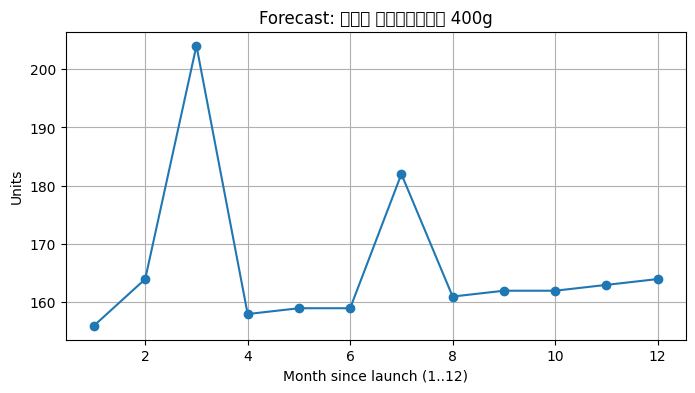

In [20]:
# 6) (선택) 특정 제품의 월별 예측 시각화
import matplotlib.pyplot as plt

example_name = submission['product_name'].iloc[0] if len(submission)>0 else None
if example_name:
    row = submission[submission['product_name']==example_name].iloc[0]
    y = [row[f'months_since_launch_{i}'] for i in range(1,13)]
    plt.figure(figsize=(8,4))
    plt.plot(range(1,13), y, marker='o')
    plt.title(f'Forecast: {example_name}')
    plt.xlabel('Month since launch (1..12)')
    plt.ylabel('Units')
    plt.grid(True)
    plt.show()
else:
    print('시각화 대상 제품이 없습니다.')


---

## 사용 팁
- **OpenAI 단계 스킵**: `OPENAI_API_KEY`가 없거나 `persona_core.json`이 없으면 자동으로 **휴리스틱 prior**를 생성합니다.
- **모델 교체**: `OPENAI_MODEL` 값을 `gpt-4.1`, `gpt-4o-mini` 등으로 수정하여 사용하세요.
- **이벤트/광고/계절성 규칙**: `EVENT_RULES`/`MACRO_PATH`를 내부 정책에 맞게 조정하세요.
- **500·900g 20% 규칙**: `rebalance_500_900()`의 `pct_900` 파라미터로 조정 가능합니다.
- **결과검증**: `submission.csv`는 `product_name`과 `months_since_launch_1..12` 형태로 저장됩니다.
